In [3]:
import numpy as np
import math

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

The most straightforward way to do this problem is to simulate. 

***__Figure out where we will bounce__***

Suppose I'm at position $(x_0, y_0)$ at time $0$ traveling in (normalized) direction $\langle a, b \rangle$. My goal is to calculate the next position on the ellipse $(x_1, y_1)$.

With a bit of basic vector calculus, my current position is $\langle x(t), y(t) \rangle$ is given by $x(t) = x_0 + t a$ and $y(t) = y_0 + t b$. Then the place I will hit on the ellipse is when
$$
\begin{align*}
4x^2 + y^2 = 100 \implies & 4(x_0 + t a)^2 + (y_0 + t b)^2 = 100 \\
    \implies & 4x_0^2 + 8t x_0 a + 4t^2 a^2 + y_0^2 + 2t y_0 b + t^2 b^2 = 100 \\
    \implies & (4a^2 + b^2) t^2 + (8x_0 a + 2y_0 b) t + (4 x_0^2 + y_0^2 - 100) = 0
\end{align*}
$$

Note if $(x_0, y_0)$ is on the ellipse, then the last term is $0$. The only time when $(x_0, y_0)$ is not on the ellipse is the first point $(0, 10.1)$, but fortunately they gave us the solution for the next point already as $(1.4, 9.6)$ so we don't need to worry about this case. So therefore, the points where the light hits the ellipse are $t = 0$ (trivially) and
$$
t = -\frac{8x_0 a + 2y_0 b}{4a^2 + b^2}.
$$

***__Figure out which direction we'll be in after bouncing__***

Now to find the direction $\langle a, b \rangle$ that the light travels when it bounces, we use the tangent line given. So if the previous (normalized) direction was $\vec{d} = \langle a_0, b_0 \rangle$ and the light hits the ellipse at the point $(x_1, y_1)$, then using the tangent slope, we get a tangent vector $\vec{t} = \langle y_1, -4x_1 \rangle$ and a normal vector $\vec{n} = \langle 4x_1, x_1 \rangle$. We can get the angle between the two vectors as
$$
\theta_{dt} = \cos^{-1}\left( \frac{\vec{d} \cdot \vec{t}}{|\vec{t}|} \right) \quad \text{and} \quad \theta_{dn} = \cos^{-1}\left( \frac{\vec{d} \cdot \vec{n}}{|\vec{n}|} \right)
$$

$\theta_{dn}$ tells us how much rotate our current vector (i.e., we need to rotate it $2\theta_{dn}$ from current position). $\theta_{dt}$ can help us determine whether to turn clockwise or counterclockwise. In particular, if $\theta{dt} > 90^\circ$, then we know we need to reflect counter clockwise. We can use a standard [rotation matrix][1] which rotates a vector $\theta$ counterclockwise (i.e., along the unit circle):
$$
R_{theta} = \begin{bmatrix} \cos \theta & -\sin \theta \\ \sin \theta & \cos \theta \end{bmatrix}
$$

From there it's just a simple simulation, and I also made a nice little animation to go with it.

[1]: https://en.wikipedia.org/wiki/Rotation_matrix

In [4]:
def rotate(vec, theta):
    x, y = vec[0], vec[1]
    ct, st = np.cos(theta), np.sin(theta)

    return np.array([ct*x - st*y, st*x + ct*y])

def angle_between(vec1, vec2):
    return np.arccos(np.dot(vec1, vec2) / (np.linalg.norm(vec1)*np.linalg.norm(vec2)))

In [20]:
# first direction given (assume light already in ellipse for ease)
pos = np.array([0, 10.1])
dir = np.array([1.4, -19.7])

# first reflection
new_pos = (1.4, -9.6)

# angle of incidence
tangent = np.array([new_pos[1], -4*new_pos[0]])
normal = np.array([4*new_pos[0], new_pos[1]])
theta = angle_between(dir, tangent)
theta2 = angle_between(dir, normal)

# # reflect over angle of incidence
# ensure you're turning clockwise or counterclockwise appropriately
new_dir = rotate(dir, 2*theta2 if theta < np.pi/2 else -2*theta2)

# now new_pos and new_dir become old_pos and old_dir
pos = new_pos
dir = new_dir

bounces = 0
print(f'after {bounces} bounces, we are at ({(pos[0]): 0.4f}, {pos[1]: 0.4f})')

positions = [(0, 10.1), (1.4, -9.6)]

while True:
    # if you come out the top then break
    if -0.01 <= pos[0] <= 0.01 and pos[1] >= 0:
        break

    x0, y0 = pos
    a0, b0 = dir
    t = -(8*x0*a0 + 2*y0*b0) / (4*a0*a0 + b0*b0)
    new_pos = x0 + t*a0, y0+ + t*b0

    # angle of incidence
    tangent = np.array([new_pos[1], -4*new_pos[0]])
    normal = np.array([4*new_pos[0], new_pos[1]])
    theta = angle_between(dir, tangent)
    theta2 = angle_between(dir, normal)

    # # reflect over angle of incidence
    # ensure you're turning clockwise or counterclockwise appropriately
    new_dir = rotate(dir, 2*theta2 if theta < np.pi/2 else -2*theta2)

    # now new_pos and new_dir become old_pos and old_dir
    pos = new_pos
    dir = new_dir

    bounces += 1
    print(f'after {bounces} bounces, we are at ({(pos[0]): 0.4f}, {pos[1]: 0.4f})')

    positions.append((new_pos))

after 0 bounces, we are at ( 1.4000, -9.6000)
after 1 bounces, we are at (-3.9906, -6.0250)
after 2 bounces, we are at ( 0.3246,  9.9789)
after 3 bounces, we are at ( 0.4165, -9.9652)
after 4 bounces, we are at (-4.4734,  4.4669)
after 5 bounces, we are at ( 1.1323,  9.7402)
after 6 bounces, we are at ( 0.0537, -9.9994)
after 7 bounces, we are at (-1.8344,  9.3026)
after 8 bounces, we are at ( 3.2882,  7.5332)
after 9 bounces, we are at (-0.2265, -9.9897)
after 10 bounces, we are at (-0.5666,  9.9356)
after 11 bounces, we are at ( 4.9043, -1.9470)
after 12 bounces, we are at (-0.8524, -9.8536)
after 13 bounces, we are at (-0.1187,  9.9972)
after 14 bounces, we are at ( 2.3747, -8.8001)
after 15 bounces, we are at (-2.6155, -8.5227)
after 16 bounces, we are at ( 0.1466,  9.9957)
after 17 bounces, we are at ( 0.7611, -9.8835)
after 18 bounces, we are at (-4.9815, -0.8587)
after 19 bounces, we are at ( 0.6369,  9.9185)
after 20 bounces, we are at ( 0.1933, -9.9925)
after 21 bounces, we ar

0
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276


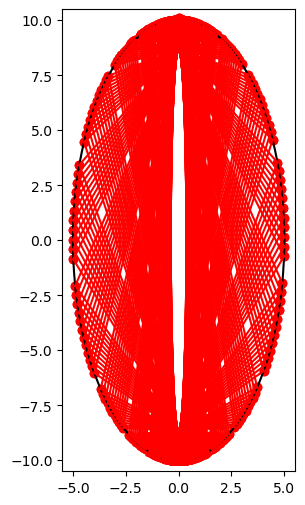

In [8]:
fig, ax = plt.subplots(1, 1, figsize = (3, 6))

# ellipse glass
xs = np.arange(-5, 5.0001, 0.0001)
ys = np.sqrt(100 - (4*(xs**2)))
ax.plot(xs, ys, color = 'k')
ax.plot(xs, -ys, color = 'k')

ax.set_xlim(-5.5, 5.5)
ax.set_ylim(-10.5, 10.5)

# draw the positions
def animate(i):
    print(i)
    if i == 0:
        ax.scatter([positions[i][0]], [positions[i][1]], color = 'red')
        return
    
    ax.scatter([positions[i-1][0], positions[i][0]], [positions[i-1][1], positions[i][1]], color = 'red')
    ax.plot([positions[i-1][0], positions[i][0]], [positions[i-1][1], positions[i][1]], color = 'red')

ani = FuncAnimation(fig, animate, frames = len(positions), interval = 1, repeat = True)
ani.save('../../pictures/problem144.gif', dpi = 300, writer = PillowWriter(fps = 2))

plt.show()

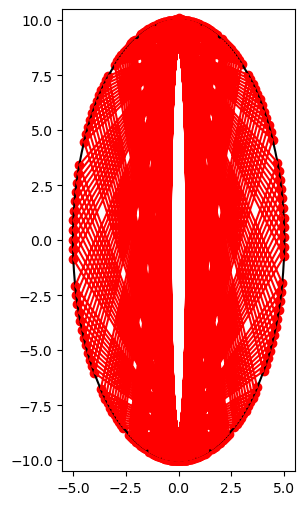

In [10]:
plt.figure(figsize = (3,6))

# ellipse glass
xs = np.arange(-5, 5.0001, 0.0001)
ys = np.sqrt(100 - (4*(xs**2)))
plt.plot(xs, ys, color = 'k')
plt.plot(xs, -ys, color = 'k')

plt.xlim(-5.5, 5.5)
plt.ylim(-10.5, 10.5)

# graph positions of light bounces
plt.plot([point[0] for point in positions], [point[1] for point in positions], color = 'red')
plt.scatter([point[0] for point in positions], [point[1] for point in positions], color = 'red')

plt.show()